# Medical Insurance Cost Analysis
by Julieta Mirensky



**Business Question**

Which customer characteristics drive medical insurance costs, and how can these insights support more accurate pricing strategies?


**Goal**

Explore the “Medical Cost Personal Dataset” to identify factors influencing medical insurance costs and support better risk segmentation.

Develop a regression model to estimate expected costs for new insurance policyholders.


**Variables**

Explanatory (Independent)

* age - age

* sex - male / female

* bmi - body mass index

* children - number of dependents (treated as categorical (*)

* smoker - yes/no

* region - northeast / southeast / southwest / northwest

Target (dependent)

* charges - medical insurance cost

----
(*) **Justification for treating 'Children' as categorical**: This variable represents the number of dependents, which is discrete. Treating it as categorical facilitates group comparisons and avoids misleading averages.

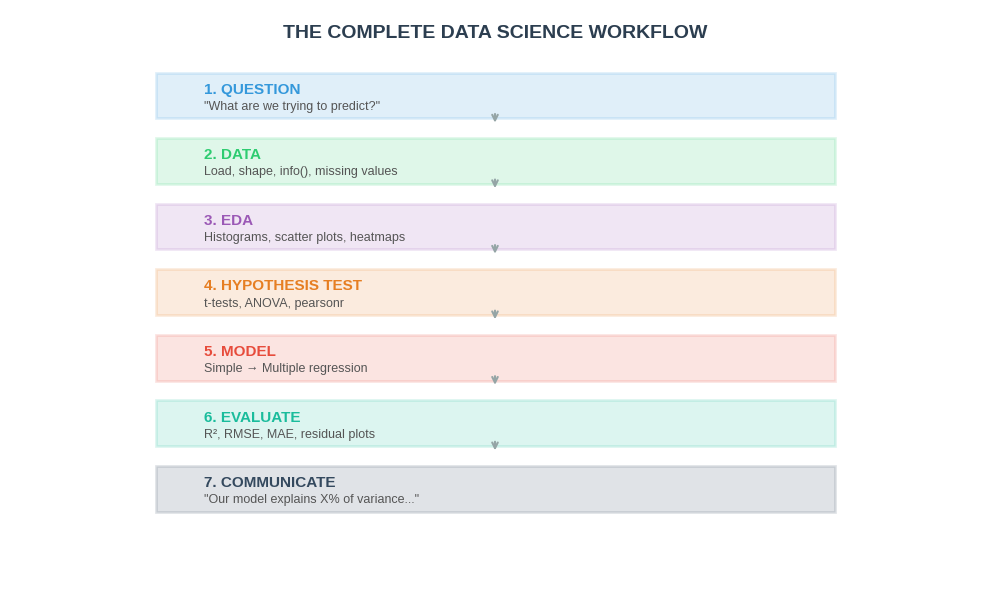

In [66]:
#  7-Step Data Science Pipeline

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'THE COMPLETE DATA SCIENCE WORKFLOW', ha='center',
        fontsize=14, fontweight='bold', color='#2c3e50')

# Steps
steps = [
    ('1. QUESTION', '"What are we trying to predict?"', '#3498db'),
    ('2. DATA', 'Load, shape, info(), missing values', '#2ecc71'),
    ('3. EDA', 'Histograms, scatter plots, heatmaps', '#9b59b6'),
    ('4. HYPOTHESIS TEST', 't-tests, ANOVA, pearsonr', '#e67e22'),
    ('5. MODEL', 'Simple → Multiple regression', '#e74c3c'),
    ('6. EVALUATE', 'R², RMSE, MAE, residual plots', '#1abc9c'),
    ('7. COMMUNICATE', '"Our model explains X% of variance..."', '#34495e'),
]

box_h = 0.8
gap = 0.35
start_y = 8.5

for i, (title, desc, color) in enumerate(steps):
    y = start_y - i * (box_h + gap)

    # Box
    ax.add_patch(plt.Rectangle((1.5, y - box_h / 2), 7, box_h,
                 facecolor=color, alpha=0.15, edgecolor=color,
                 linewidth=2, zorder=2))

    # Step title
    ax.text(2.0, y + 0.1, title, fontsize=11, fontweight='bold',
            color=color, va='center')

    # Description
    ax.text(2.0, y - 0.2, desc, fontsize=9, color='#555555', va='center')

    # Arrow to next step
    if i < len(steps) - 1:
        arrow_y = y - box_h / 2 - gap / 2
        ax.annotate('', xy=(5, arrow_y + 0.05), xytext=(5, arrow_y + gap - 0.05),
                    arrowprops=dict(arrowstyle='->', lw=1.5, color='#95a5a6'))

plt.tight_layout()
plt.show()

In [67]:
# -----------------------------
# Libraries
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from scipy import stats
from scipy.stats import ttest_ind, f_oneway  #pearson no?

#for regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported!")


All libraries imported!


# Dataset Load

In [68]:
df_raw= pd.read_csv("insurance.csv")

print(f'Database has a shape of {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

print("\ncolumns names, nulls and data types\n")
print(df_raw.info())

Database has a shape of 1338 rows x 7 columns

columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


# Data Cleaning

In [69]:
# == Convert to categorical variables ==

df = df_raw.copy()

columns = ['sex', 'children', 'smoker', 'region' ]
for col in columns:
    df[col] = df[col].astype('category')

print(df.dtypes)  # verification

print("\nFirst 5 rows:")
display(df.head())

age            int64
sex         category
bmi          float64
children    category
smoker      category
region      category
charges      float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [70]:
# ==  missing values ==

missing_counts = df_raw.isnull().sum()
missing_pct = ((missing_counts / len(df_raw)) * 100).round(1)

missing = pd.DataFrame({
    'Missing Count': missing_counts,
     'Missing %': missing_pct
 }).query("`Missing Count` > 0").sort_values(by='Missing %', ascending=False)

display(missing)

# no missing values found!


,Missing Count,Missing %


In [71]:
# == duplicates==

dup_count = df_raw.duplicated().sum()
print(f"Duplicate rows : {dup_count}")

# 1 duplicate record in the dataframe
# It is decided not to delete it, as it likely represents two different clients with the same characteristics.
# There is no evidence to the contrary; this dataset is a fragment of a larger database, with more fragmented information.


Duplicate rows : 1


Summary Data Cleaning
* 1,338 rows × 7 columns

* Categorical conversion: sex, children, smoker, region

* Missing values: None

* Duplicate rows: 1 duplicate, kept


# Exploratory Data Analysis (EDA)

In [72]:
# ===========================================
# Basic statistics
# ===========================================

# Numerical
display(df.describe())

# Categorical
display(df.describe(include='category'))

,age,bmi,charges
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265
std,14.049960,6.098187,12110.011237
min,18.000000,15.960000,1121.873900
25%,27.000000,26.296250,4740.287150
50%,39.000000,30.400000,9382.033000
75%,51.000000,34.693750,16639.912515
max,64.000000,53.130000,63770.428010


,sex,children,smoker,region
count,1338,1338,1338,1338
unique,2,6,2,4
top,male,0,no,southeast
freq,676,574,1064,364


The dataset represents a population of middle-aged adults with slightly elevated BMI and relatively few dependents. Medical insurance charges show high variability and positive skew.

The data is relatively balanced by gender but dominated by non-smokers.
Southeast region has the highest representation.

In [73]:
# bmi = body Mass Index; according to the World Health Organization's classification:

# BMI	          classification
# < 18.5	      Underweight                         Increased risk
# 18.5 – 24.9 	Normal weight                       normal
# 25 – 29.9	    Overweight                          Moderate risk
# 30 – 34.9	    Class I Obesity                     High risk
# 35 – 39.9	    Class II Obesity                    High risk
# ≥ 40	        Class III Obesity (Severe Obesity)  High risk

bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
labels = [
    'Underweight',
    'Normal weight',
    'Overweight',
    'Obesity Class I',
    'Obesity Class II',
    'Obesity Class III'
]

df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)   # right=False  [ a, b)

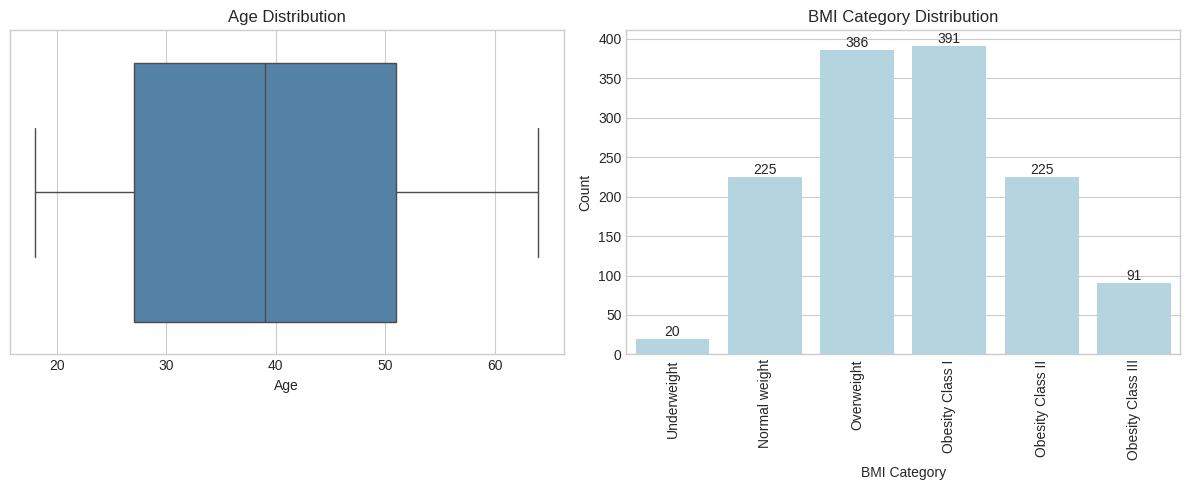

The dataset reflects an adult population with a predominance of individuals of overweight or Obesity Class I.


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Boxplot Age ---
sns.boxplot(x=df['age'], ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# --- Countplot  BMI ---
order = [
'Underweight',
'Normal weight',
'Overweight',
'Obesity Class I',
'Obesity Class II',
'Obesity Class III'
]

ax = sns.countplot(data=df, x='bmi_category', order=order, ax=axes[1], color='lightblue')

axes[1].set_title('BMI Category Distribution')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

print('The dataset reflects an adult population with a predominance of individuals of overweight or Obesity Class I.')

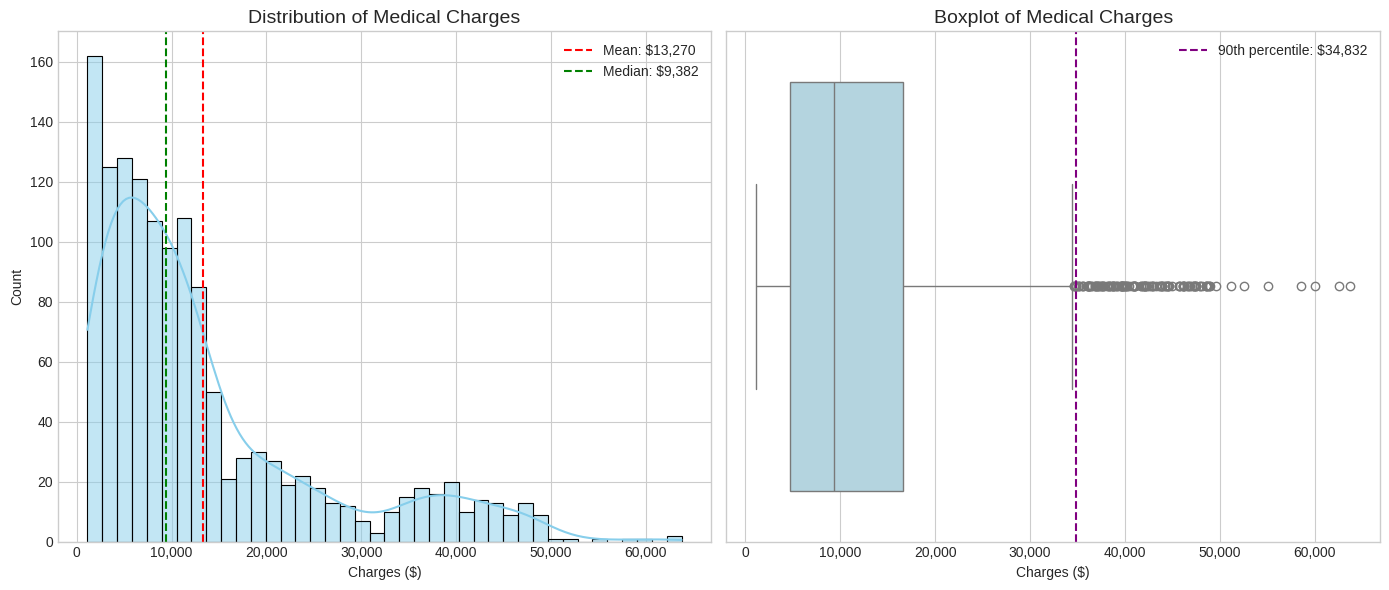

In [75]:
# Distribution of medical charges, zoom in outliers

top_10pct = df['charges'].quantile(0.90)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(df['charges'], kde=True, bins=40, color='skyblue', ax=axes[0])
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='green', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
axes[0].set_title('Distribution of Medical Charges', fontsize=14)
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
axes[0].legend()

sns.boxplot(x=df['charges'], ax=axes[1], color='lightblue')
axes[1].axvline(top_10pct, color='purple', linestyle='--', label=f'90th percentile: ${top_10pct:,.0f}')
axes[1].set_title('Boxplot of Medical Charges', fontsize=14)
axes[1].set_xlabel('Charges ($)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [76]:
charges = df['charges']
charges_desc = stats.describe(charges)

median_charges= np.median(charges)   # median and Standard deviation not included in scipy
std_charges = np.sqrt(charges_desc.variance)

print(f"Mean charges: ${charges_desc.mean:,.0f}")
print(f"Median charges: ${median_charges:,.0f}")
print(f"Standard deviation: ${std_charges:,.0f}")
print(f"Skewness: {stats.skew(charges):.2f}")
print(f"Kurtosis: {stats.kurtosis(charges):.2f}\n")


Mean charges: $13,270
Median charges: $9,382
Standard deviation: $12,110
Skewness: 1.51
Kurtosis: 1.60



The distribution of medical charges is highly skewed to the right, with a mean of $13.270, and a median of 9.382. Most individuals have moderate costs below the mean, while a small number incur very high expenses.

The large standard deviation and moderate kurtosis show high variability with some extreme values.

## Correlation Heatmap

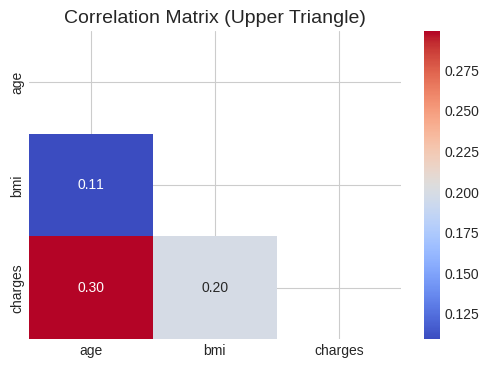

In [77]:
corr = df[['age','bmi','charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle

plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask)
plt.title('Correlation Matrix (Upper Triangle)', fontsize=14)
plt.show()

# 	Correlation   Weak	0.0 – 0.3
#                 Moderate	0.3 – 0.7
#                 Strong	0.7 – 1.0



* Correlations are weak, they all state <= 0.3. No single numerical feature dominates.

* No single numerical factor explains the variability of charges; it is necessary to consider interaction with categorical variables.


* correlation between age and BMI = 0.11 indicates a very weak linear relationship; multicollinearity between these variables is not a concern.

## Relation of each variable on medical costs

Using a hue is necessary to understand group separation. This is an case of use for **Simpson’s paradox**, where trends in the overall data differ from trends within subgroups.

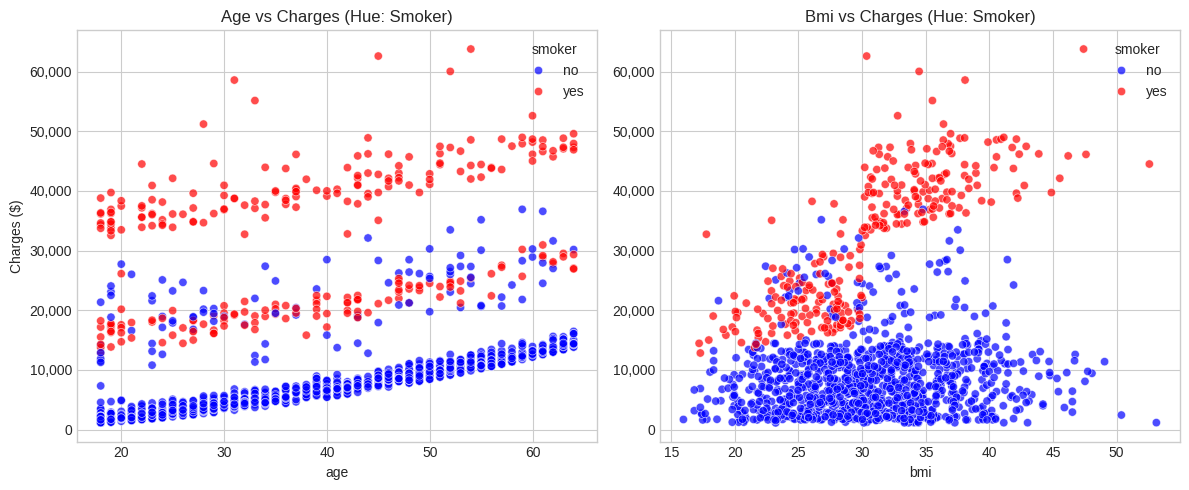


Smoking is an important driver


In [78]:
#Scatterplots Age and BMI vs Chargues with hue smoker

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, var in zip(axes, ['age','bmi']):
    sns.scatterplot(x=var, y='charges', data=df, hue='smoker',
                    palette={'yes':'red','no':'blue'}, alpha=0.7, ax=ax)
    ax.set_ylabel('Charges ($)') if var=='age' else ax.set_ylabel('')
    ax.set_title(f'{var.capitalize()} vs Charges (Hue: Smoker)')
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

print('\nSmoking is an important driver')

* Clear separation between smokers vs non-smokers

* Age → positive trend

* BMI → effect stronger in smokers


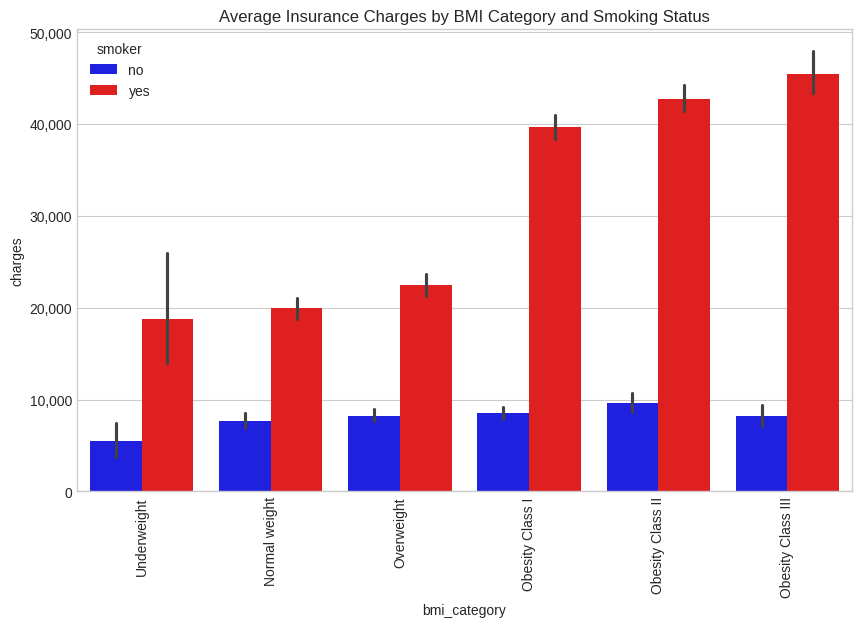


Insurance costs clearly increase with BMI, but smoking raises expenses much more sharply
Obesity with smoking = highest risk profiles.


In [79]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=df,
    x='bmi_category',
    y='charges',
    hue='smoker',
    palette={'yes':'red','no':'blue'}
)

plt.title('Average Insurance Charges by BMI Category and Smoking Status')
plt.xticks(rotation=90)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

print('\nInsurance costs clearly increase with BMI, but smoking raises expenses much more sharply')
print('Obesity with smoking = highest risk profiles.')


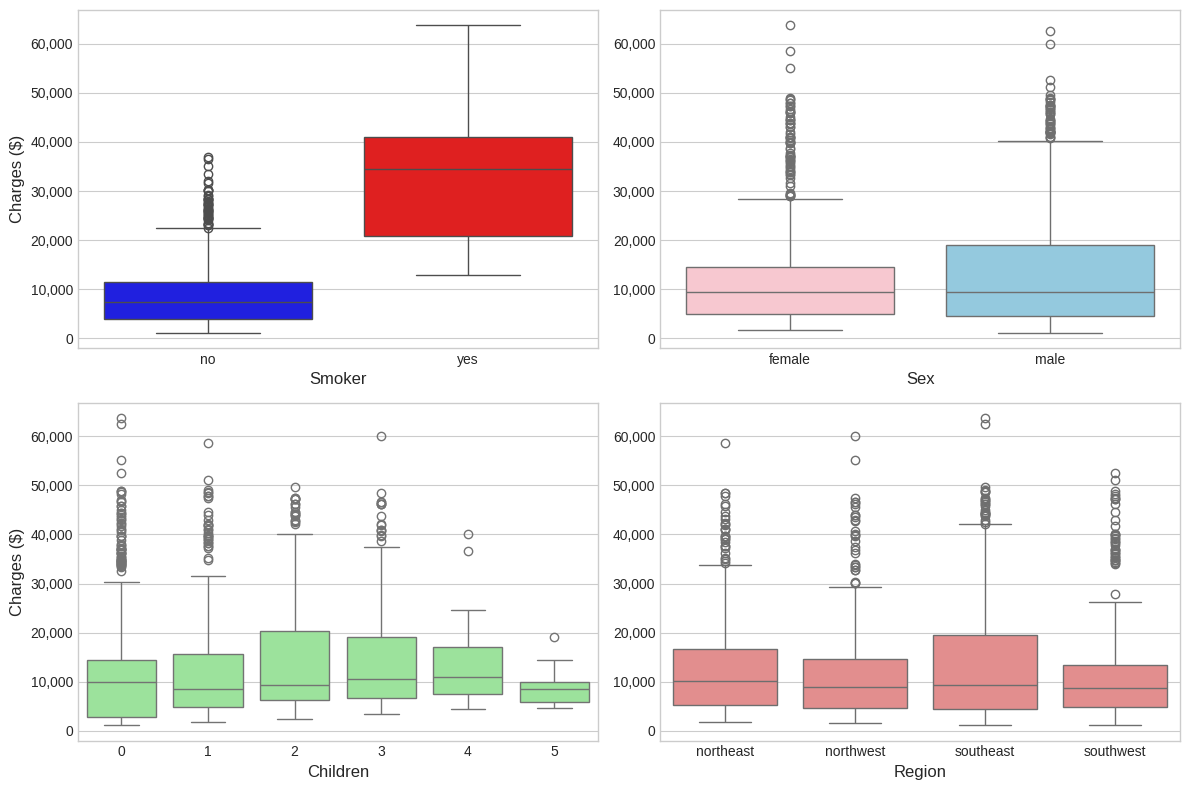

In [80]:
# Categorical Variables vs Charges

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

cat_vars = ['smoker', 'sex', 'children', 'region']

palette_dict = {
    'smoker': {'yes':'red','no':'blue'},
    'sex': {'male':'skyblue','female':'pink'},
    'children': 'lightgreen',
    'region': 'lightcoral'
}

for i, var in enumerate(cat_vars):
    if var in ['smoker','sex']:
        sns.boxplot(
            x=var, y='charges', hue=var, data=df,
            palette=palette_dict[var], dodge=False, legend=False, ax=axes[i]
        )
    else:
        sns.boxplot(x=var, y='charges', data=df, color=palette_dict[var], ax=axes[i])

    axes[i].set_xlabel(var.capitalize(), fontsize=12)
    axes[i].set_ylabel('Charges ($)' if i in [0,2] else '', fontsize=12)
    axes[i].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

**Smoking** is the most significant categorical factor determining medical costs.

**Sex and region** have a minor impact.

**Number of children** =  very slight increase, which could be considered in insurance segmentation (More children → more median, more dispersion, some high outliers).


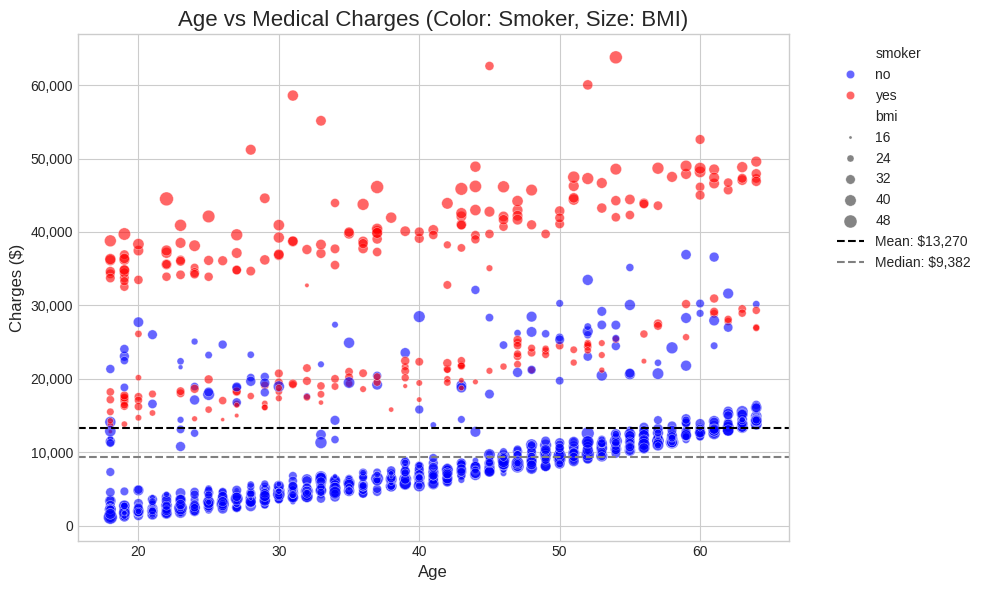

In [81]:
# Bubble Plot: Age, Charges, BMI, Smoker (4 variables at the same time)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='age',
    y='charges',
    hue='smoker',
    size='bmi',
    sizes=(5, 100),
    palette={'yes':'red','no':'blue'},
    alpha=0.6,
    data=df
)

mean_val = df['charges'].mean()
median_val = df['charges'].median()
plt.axhline(mean_val, color='black', linestyle='--', label=f'Mean: ${mean_val:,.0f}')
plt.axhline(median_val, color='gray', linestyle='--', label=f'Median: ${median_val:,.0f}')


plt.title('Age vs Medical Charges (Color: Smoker, Size: BMI)', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**EDA Insights**

* Smoking → strongest driver of medical charges

* Age → charges increase with age

* BMI → moderate effect, more pronounced in smokers

* Children → slight effect, mostly visible in top outliers

* Sex & region → minor influence

* charges distribution → positively skewed with extreme values


| Variable | Impact on charges | Comment |
| ----------|--------------------|------------|
| Smoker | Very high | Huge difference between yes/no |
| Age | Medium | Positive, gradual |
| BMI | Medium | More relevant in smokers |
| Children | Low | Only visible in outliers |
| Sex | Low | Slight difference |
| Region | Low | Similar distributions |


# Hypothesis Testing (T-test + ANOVA)


Step 1: State hypothesis
  H0: μ_smokers = μ_nonsmokers
  H1: μ_smokers ≠ μ_nonsmokers
  α = 0.05

Step 2: Examine the groups
  smokers : n=274, mean=$32,050, std=$11,542
  nonsmokers: n=1064, mean=$8,434, std=$5,994
 Observed difference: $23,616

Step 3: Run the test | Welch's T-test: Charges by Smoker Status
T-statistic: 32.75
P-value: 0.00000
P-value < 0.001 (extremely significant)

Step 4: Decision
 Reject H0: There is a significant difference in charges between smokers and non-smokers



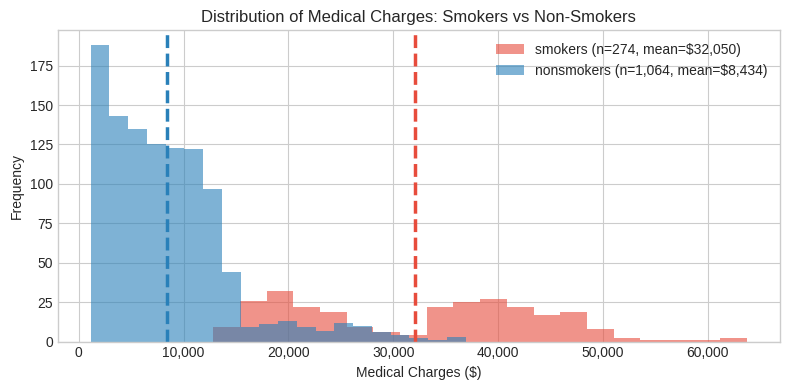


Smoking status has a statistically significant impact on medical charges.
Smokers incur substantially higher costs on average.
Therefore, smoking status should be considered a key variable in insurance pricing models.


In [82]:
# Do smokers generate higher medical insurance costs than non-smokers?
# T-test: Smokers vs Non-Smokers

smokers = df[df['smoker']=='yes']['charges']
nonsmokers = df[df['smoker']=='no']['charges']

print("\nStep 1: State hypothesis")
print(f"  H0: μ_smokers = μ_nonsmokers")
print(f"  H1: μ_smokers ≠ μ_nonsmokers")
print(f"  α = 0.05")

print("\nStep 2: Examine the groups")
print(f"  smokers : n={len(smokers)}, mean=${np.mean(smokers):,.0f}, std=${np.std(smokers, ddof=1):,.0f}")
print(f"  nonsmokers: n={len(nonsmokers)}, mean=${np.mean(nonsmokers):,.0f}, std=${np.std(nonsmokers, ddof=1):,.0f}")
print(f" Observed difference: ${np.mean(smokers) - np.mean(nonsmokers):,.0f}")

print("\nStep 3: Run the test | Welch's T-test: Charges by Smoker Status")
t_stat, p_val = ttest_ind(smokers, nonsmokers, equal_var=False)    # #equal_var=False --> Welch's t-test
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.5f}")
if p_val < 0.001:
    print("P-value < 0.001 (extremely significant)")

print("\nStep 4: Decision")
alpha = 0.05
if p_val < alpha:
    print(" Reject H0: There is a significant difference in charges between smokers and non-smokers\n")
else:
    print(" Fail to reject H0: No significant difference\n")

# Histogram
fig, ax = plt.subplots(figsize=(8,4))

ax.hist(smokers, bins=20, alpha=0.6, color="#E74C3C",
        label=f"smokers (n={len(smokers):,.0f}, mean=${np.mean(smokers):,.0f})")
ax.hist(nonsmokers, bins=20, alpha=0.6, color="#2980B9",
        label=f"nonsmokers (n={len(nonsmokers):,.0f}, mean=${np.mean(nonsmokers):,.0f})")

ax.axvline(np.mean(smokers), color="#E74C3C", lw=2.5, linestyle="--")
ax.axvline(np.mean(nonsmokers), color="#2980B9", lw=2.5, linestyle="--")

ax.set_title("Distribution of Medical Charges: Smokers vs Non-Smokers")
ax.set_xlabel("Medical Charges ($)")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print("\nSmoking status has a statistically significant impact on medical charges.")
print("Smokers incur substantially higher costs on average.")
print("Therefore, smoking status should be considered a key variable in insurance pricing models.")


Step 1: State hypothesis
  H0: All regions have the same mean charges
  H1: At least one region has a different mean
  α = 0.05

Step 2: Examine the groups
  northeast: n=324, mean=$13,406, std=$11,256
  southeast: n=364, mean=$14,735, std=$13,971
  southwest: n=325, mean=$12,347, std=$11,557
  northwest: n=325, mean=$12,418, std=$11,072

Step 3: Run the test | ANOVA
F-statistic: 2.97
P-value: 0.03089

Step 4: Decision
 Reject H0: At least one region differs in average charges



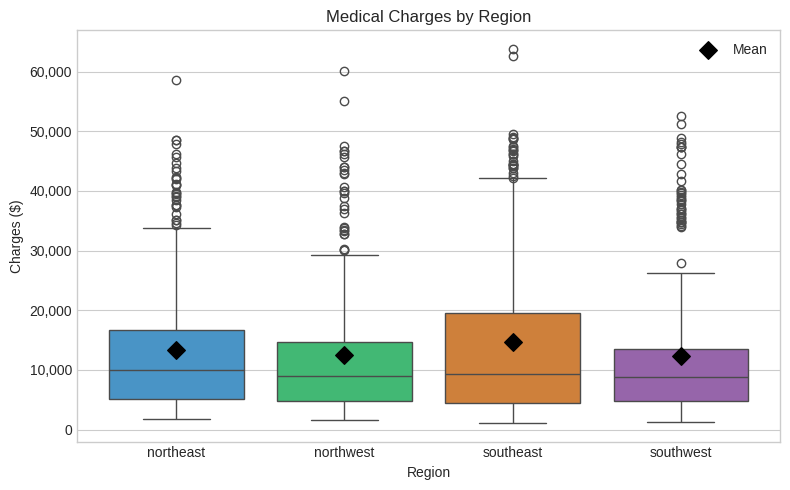


Medical charges appear broadly similar across regions, with overlap in distributions.
Geography has a limited effect on insurance costs.


In [83]:
# Do average medical charges differ across regions?
# ANOVA: Charges by Region

print("\nStep 1: State hypothesis")
print("  H0: All regions have the same mean charges")
print("  H1: At least one region has a different mean")
print("  α = 0.05")

northeast = df[df['region']=='northeast']['charges']
southeast = df[df['region']=='southeast']['charges']
southwest = df[df['region']=='southwest']['charges']
northwest = df[df['region']=='northwest']['charges']

print("\nStep 2: Examine the groups")
for name, group in zip(
    ['northeast','southeast','southwest','northwest'],
    [northeast, southeast, southwest, northwest]
):
    print(f"  {name}: n={len(group)}, mean=${np.mean(group):,.0f}, std=${np.std(group, ddof=1):,.0f}")

print("\nStep 3: Run the test | ANOVA")
f_stat, p_val = f_oneway(northeast, southeast, southwest, northwest)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_val:.5f}")

print("\nStep 4: Decision")
alpha = 0.05
if p_val < alpha:
    print(" Reject H0: At least one region differs in average charges\n")
else:
    print(" Fail to reject H0: No significant regional differences\n")


plt.figure(figsize=(8,5))

region_colors = {
    'northeast': '#3498DB',
    'northwest': '#2ECC71',
    'southeast': '#E67E22',
    'southwest': '#9B59B6'
}

sns.boxplot(
    x='region',
    y='charges',
    hue='region',
    data=df,
    palette=region_colors,
    legend=False,
    zorder=1
)

means_region = df.groupby('region', observed=True)['charges'].mean()

# means = diamonds
for i, region in enumerate(means_region.index):
    plt.scatter(
        i,
        means_region[region],
        color='black',
        marker='D',
        s=80,
        label="Mean" if i == 0 else ""
    )

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges ($)")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.tight_layout()
plt.show()

print ('''\nMedical charges appear broadly similar across regions, with overlap in distributions.
Geography has a limited effect on insurance costs.''')



---



# Predicting Medical Insurance Costs - Machine Learning

There are two clear objectives:

1 - understand which factors influence medical insurance costs (and how);

2 - build a **regression model** to estimate insurance expenses for new clients.

## Dataset Preparation

In [84]:
# ML approach: sklearn LinearRegression

# Prepare data, separate y from x

# Target variable:
y = df['charges']

# Features:
X = df.drop(columns=['charges', 'bmi_category'])   # It is used regular BMI column

  # sex, smoker, children, region = categorical -->  one-hot encoding
  # age, bmi = numericals --> normalization (after split)

# one-hot encoding - Convert categorical variables into dummy variables
# drop_first=True avoids multicollinearity in regression models
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

print('X Encoded')
X_encoded.head()
      #result
      # age
      # bmi
      # sex_male           sex_female =  base line
      # children_1         children_0 = base line
      # children_2
      # children_3
      # children_4
      # children_5
      # smoker_yes         smoker_no  =  base line
      # region_northwest   region_northeast = base line
      # region_southeast
      # region_southwest

X Encoded


,age,bmi,sex_male,children_1,children_2,children_3,children_4,children_5,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,0,0,0,0,1,0,0,1
1,18,33,1,1,0,0,0,0,0,0,1,0
2,28,33,1,0,0,1,0,0,0,0,1,0
3,33,22,1,0,0,0,0,0,0,1,0,0
4,32,28,1,0,0,0,0,0,0,1,0,0


## Train/Test Split & Scaling

In [85]:
# Split in 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42)

# Scaling Numerical feature to Normal Distribution with  mean = 0 and std = 1, all have the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('''Dataset ready for ML!
X_train_scaled
X_test_scaled
y_train
y_test''')


Dataset ready for ML!
X_train_scaled
X_test_scaled
y_train
y_test


## Linear Regression Model
A linear regression model is train to predict charges & interpret the impact of each feature.

In [86]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)  #training part

y_pred = model.predict(X_test_scaled)  #prediction part


## Evaluation: How well the model work?

In [87]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f" Model Evaluation Metrics:\n")
print(f"R² (Coefficient of Determination): {r2:.3f} --> the model explains {r2*100:.1f}% of of the variation in charges")

if r2 < 0.5:
    interpretation = "The model explains less than half of the variance in medical charges, so predictions are only moderately reliable."
elif r2 < 0.8:
    interpretation = "The model explains a good portion of the variance in medical charges, giving reasonably accurate predictions."
else:
    interpretation = "The model explains most of the variance in medical charges, providing highly reliable predictions."

print(f"Interpretation: {interpretation}")

print(f"\nMSE (Mean Squared Error): ${mse:,.0f}  -squared-")
print(f"RMSE (Root Mean Squared Error): on avg, off by ${rmse:,.0f}") #on average we are off this much, in monetary units
print(f"MAE (Mean Absolute Error): on avg, |error| is ${mae:,.0f}")  #MAE → average error in monetary units ignoring direction

print("\nModel performance is strong for a simple linear regression, a few key lifestyle variables explain most insurance cost variability.")


 Model Evaluation Metrics:

R² (Coefficient of Determination): 0.783 --> the model explains 78.3% of of the variation in charges
Interpretation: The model explains a good portion of the variance in medical charges, giving reasonably accurate predictions.

MSE (Mean Squared Error): $33,727,509  -squared-
RMSE (Root Mean Squared Error): on avg, off by $5,808
MAE (Mean Absolute Error): on avg, |error| is $4,210

Model performance is strong for a simple linear regression, a few key lifestyle variables explain most insurance cost variability.


## Visualizations for regression

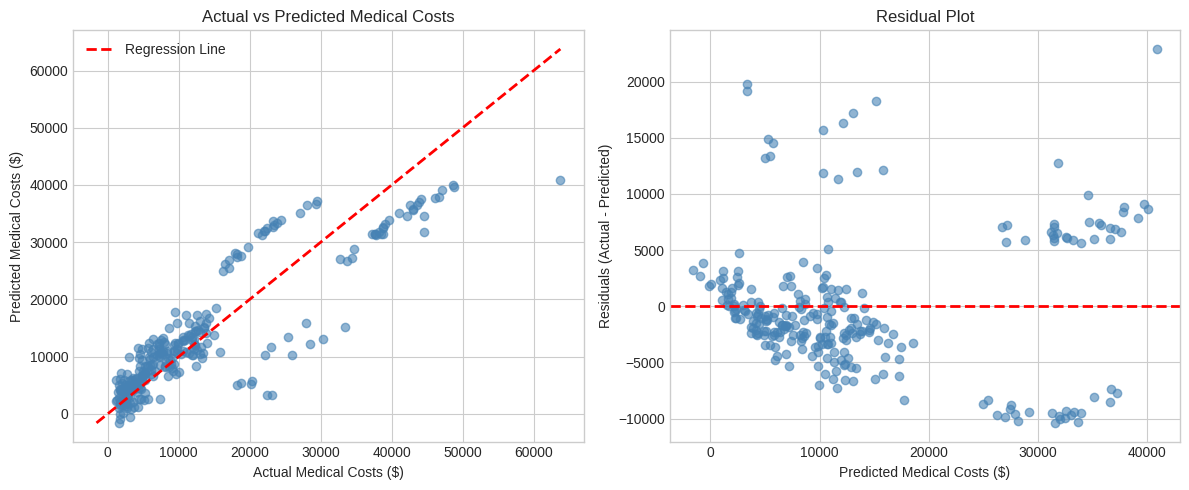


Residual plot: points should scatter randomly around the red line.


In [92]:
# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -----------------------------
# 1. Actual vs Predicted
# -----------------------------
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val],
             linestyle='--', color='red', linewidth=2, label='Regression Line')

axes[0].set_xlabel('Actual Medical Costs ($)')
axes[0].set_ylabel('Predicted Medical Costs ($)')
axes[0].set_title('Actual vs Predicted Medical Costs')
axes[0].legend()

# -----------------------------
# 2. Residual Plot
# -----------------------------
residuals = y_test - y_pred

axes[1].scatter(y_pred, residuals, alpha=0.6, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)

axes[1].set_xlabel('Predicted Medical Costs ($)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')


plt.tight_layout()
plt.show()

print("\nResidual plot: points should scatter randomly around the red line.")


## Intercept & Coefficients

In [89]:
# intercept
intercept = model.intercept_
print(f"Intercept: ${intercept:.2f}")
print()

# model coefficients, sorted by importance
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Larger coefficients indicate a stronger relative impact on the predicted cost (features are standardized).")
display(coefficients.round(2))


Intercept: $13346.09

Larger coefficients indicate a stronger relative impact on the predicted cost (features are standardized).


,Feature,Coefficient
8,smoker_yes,9562.04
0,age,3630.88
1,bmi,2022.12
4,children_2,603.92
6,children_4,469.34
5,children_3,203.00
3,children_1,138.25
7,children_5,109.30
2,sex_male,-14.89
9,region_northwest,-176.88


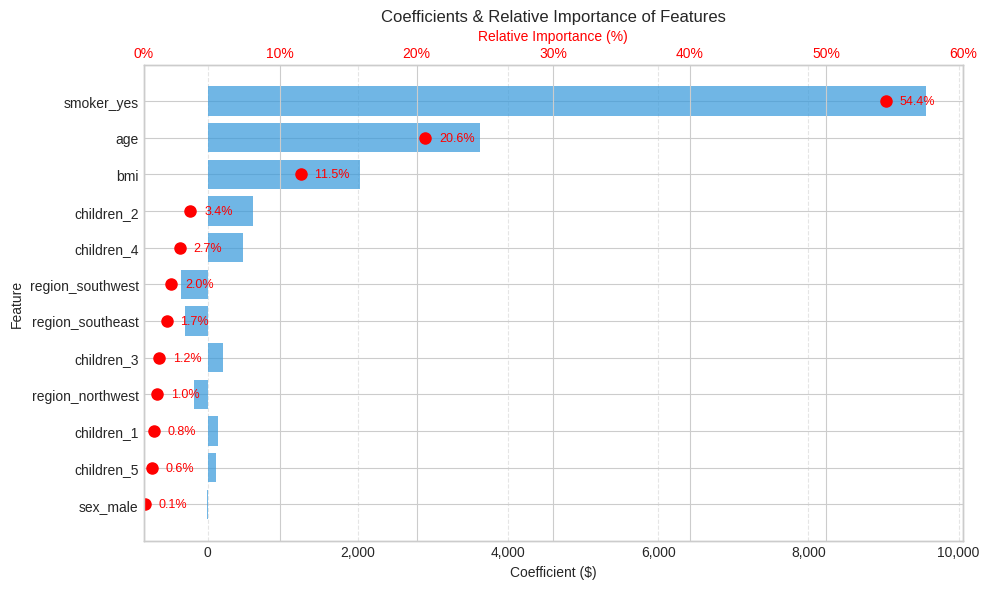


smoker_yes: largest impact, significantly increases cost.
age and bmi: positive effect, older age or higher BMI → higher cost.
children, sex, and region: smaller effects.


In [90]:
# Chart: Features on Medical Insurance Charges: Coefficients & Relative Importance

coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
})
coefficients['Importance'] = coefficients['Coefficient'].abs() / coefficients['Coefficient'].abs().sum() * 100
coefficients_sorted = coefficients.sort_values(by='Importance', ascending=True)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.barh(coefficients_sorted['Feature'], coefficients_sorted['Coefficient'], color='#3498DB', alpha=0.7)
ax1.set_xlabel("Coefficient ($)")
ax1.set_ylabel("Feature")
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax2 = ax1.twiny()
ax2.plot(coefficients_sorted['Importance'], coefficients_sorted['Feature'], 'ro', markersize=8)
ax2.set_xlabel("Relative Importance (%)", color='red')
ax2.tick_params(axis='x', colors='red')
ax2.set_xlim(0, 60)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())

for x, y, imp in zip(coefficients_sorted['Importance'], coefficients_sorted['Feature'], coefficients_sorted['Importance']):
    ax2.text(x + 1, y, f"{imp:.1f}%", color='red', va='center', fontsize=9)

plt.title("Coefficients & Relative Importance of Features")
plt.tight_layout()
plt.show()

print('''\nsmoker_yes: largest impact, significantly increases cost.
age and bmi: positive effect, older age or higher BMI → higher cost.
children, sex, and region: smaller effects.''')

## Equation = model structure

Predicted Charges =

13346.09

+3629.26  * age

+2023.63 * bmi

−15.67  * sex_male

+140.46  * children_1  + 600.07 * children_2  + 200.38 * children_3  + 468.03 * children_4  + 110.83 * children_5

+**9560.55** * smoker_yes

−179.37 * region_northwest − 295.27 * region_southeast − 355.25 * region_southwest

## Predicting a New Client
Features: 40 years old, BMI 30, smoker, male, living in the Southeast region, without kids.

In [91]:
new_client = pd.DataFrame({
    'age':[40],
    'bmi':[30],
    'sex_male':[1],
    'children_1':[0],
    'children_2':[0],
    'children_3':[0],
    'children_4':[0],
    'children_5':[0],
    'smoker_yes':[1],
    'region_northwest':[0],
    'region_southeast':[1],
    'region_southwest':[0]
})

new_client_scaled = scaler.transform(new_client)

prediction = model.predict(new_client_scaled)

print(f"Predicted insurance cost for the new client: ${prediction[0]:,.0f}")

Predicted insurance cost for the new client: $31,560


## Insights


BUSINESS QUESTION: Which customer characteristics drive medical insurance costs, and how can these insights support more accurate pricing strategies?


KEY FINDINGS:
- Lifestyle and demographic factors strongly influence healthcare costs.
- Smoking status is the dominant risk factor
- Age and BMI also contribute meaningfully to higher expenses.
- Children, sex, and region appear to have a relatively small effect.


CONCLUSION:
- The full model (6 features) explains a large portion of the variability  in insurance charges: 78.3%
- On average, predictions differ from the actual charges by about $5,808.


SUGGESTIONS / NEXT STEPS:
- Testing a reduced model focused on the 3 most relevant variables: smoking status, age and BMI.
- This may improve interpretability while maintaining most of the predictive power.